# Writing your own Neural Network code

In [1]:
import autograd.numpy as np
import pandas as pd
import time
from sklearn.model_selection import train_test_split

# custom imports
from source.runge_preprocessing import x, x_train, x_train_scaled, x_test, y, y_noise, y_train, y_test, ETA_VALUES, LAMBDA_VALUES
from source.neural_network import NN
import source.schedulers as schedulers
from source.cost_functions import mse
from source.utils import neural_network_loop, create_activations_layderdim
from source.plotting import plot_runges
from source.plotting import plot_heatmap
import source.activation_functions as activation_functions


# OLS regression

### Results from project 1
Results from running code in project 1, jupyter file "assignment1_a_b.ipynb"

In section "Explore OLS in regards to polynomial degree, with noise" a small code were added to get smallest MSE Test value, and index for which polynomial degree.

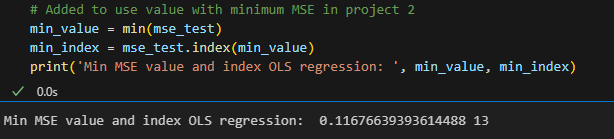

Hence, the best MSE on the test dataset was achieved when using polynomial degree 14.

# OLS with FFNN

From report 1 best results are acheived with learning rate 0.5 and 600 iterations. This can be seen in figure 8

# Own implementation of Neural Network


In [2]:

#MAX_ITERATIONS = 600
#ETA= 0.5    # eta 0.5 in runge_preprocessing ETAs?

ITERATIONS = 10
MOMENTUM = 0.9
VERBOSE = False
SHOW_PLOT = True
SAVE_FIGURE = True
OPTIMIZER = 'ADAM'

SAVE_FIGURE = True
SHOW_PLOT = True



### Own implementation of FFNN

Hidden layers (50,100)

In [3]:
# Settings for own implementation

# Activation output always linear with regression
ACTIVATION_FUNCTION_OUTPUT = activation_functions.linear
ACTIVATION_FUNCTION_OUTPUT_DERIVATIVE = activation_functions.linear_derivative

# Hidden layers
ACTIVATION_FUNCTION = activation_functions.RELU
ACTIVATION_FUNCTION_DERIVATIVE = activation_functions.RELU_derivative
RUNGE_HIDDEN = (50, 100)

# Generate list of activation functions, and dimensions of layers
activations, activations_derivative, _dim = create_activations_layderdim(ACTIVATION_FUNCTION, ACTIVATION_FUNCTION_DERIVATIVE, ACTIVATION_FUNCTION_OUTPUT, ACTIVATION_FUNCTION_OUTPUT_DERIVATIVE, RUNGE_HIDDEN, y_train, x_train_scaled)


In [4]:

# Hidden layers 50, 100
print(f'Dimensions of input, hidden, and output layer:\n{_dim}')

runge_NN = NN(dims = _dim, activation_funcs = activations, activation_ders = activations_derivative)

results_sgd = neural_network_loop(runge_NN, ETA_VALUES, LAMBDA_VALUES, 'SGD', ITERATIONS, x_train_scaled, y_train, x_test, y_test, momentum_val=0.9, verbose=True)
"""
results_rmsprop = neural_network_loop(runge_NN, ETA_VALUES, LAMBDA_VALUES, 'RMSprop', ITERATIONS, x_train_scaled, y_train, x_test, y_test, momentum_val=0.9, verbose=True)
results_adam_no_penalty = neural_network_loop(runge_NN, ETA_VALUES, LAMBDA_VALUES, 'ADAM', ITERATIONS, x_train_scaled, y_train, x_test, y_test, momentum_val=0.9, verbose=True)
results_adam_L1 = neural_network_loop(runge_NN, ETA_VALUES, LAMBDA_VALUES, 'ADAM_L1', ITERATIONS, x_train_scaled, y_train, x_test, y_test, momentum_val=0.9, verbose=True)
results_adam_L2 = neural_network_loop(runge_NN, ETA_VALUES, LAMBDA_VALUES, 'ADAM_L2', ITERATIONS, x_train_scaled, y_train, x_test, y_test, momentum_val=0.9, verbose=True)
"""

Dimensions of input, hidden, and output layer:
[1, 50, 100, 1]

Training with: optimizer=SGD, lr=0.1, lambda=0.01, iteration=10
Using scheduler: momentum with Eta=0.1

Training with: optimizer=SGD, lr=0.1, lambda=0.005994842503189409, iteration=10
Using scheduler: momentum with Eta=0.1

Training with: optimizer=SGD, lr=0.1, lambda=0.003593813663804626, iteration=10
Using scheduler: momentum with Eta=0.1

Training with: optimizer=SGD, lr=0.1, lambda=0.0021544346900318843, iteration=10
Using scheduler: momentum with Eta=0.1

Training with: optimizer=SGD, lr=0.1, lambda=0.001291549665014884, iteration=10
Using scheduler: momentum with Eta=0.1


c:\Users\brumor\phd\4155\data_analysis_ml_projects\assignment2\Code\source\neural_network.py:262: RuntimeWarning: overflow encountered in matmul
  dC_da = dC_dz @ W.T
c:\Users\brumor\phd\4155\data_analysis_ml_projects\assignment2\Code\source\neural_network.py:268: RuntimeWarning: invalid value encountered in matmul
  gradient_weights = layer_input.T @ dC_dz
c:\Users\brumor\phd\4155\data_analysis_ml_projects\assignment2\Code\source\neural_network.py:262: RuntimeWarning: invalid value encountered in matmul
  dC_da = dC_dz @ W.T
c:\Users\brumor\phd\4155\data_analysis_ml_projects\assignment2\Code\source\neural_network.py:232: RuntimeWarning: invalid value encountered in matmul
  z = a @ W + b
c:\Users\brumor\phd\4155\data_analysis_ml_projects\assignment2\Code\source\neural_network.py:265: RuntimeWarning: invalid value encountered in multiply
  dC_dz = dC_da * activation_der(z)
c:\Users\brumor\phd\4155\data_analysis_ml_projects\assignment2\Code\source\neural_network.py:232: RuntimeWarning: 


Training with: optimizer=SGD, lr=0.1, lambda=0.000774263682681127, iteration=10
Using scheduler: momentum with Eta=0.1

Training with: optimizer=SGD, lr=0.1, lambda=0.0004641588833612782, iteration=10
Using scheduler: momentum with Eta=0.1

Training with: optimizer=SGD, lr=0.1, lambda=0.0002782559402207126, iteration=10
Using scheduler: momentum with Eta=0.1

Training with: optimizer=SGD, lr=0.1, lambda=0.0001668100537200059, iteration=10
Using scheduler: momentum with Eta=0.1

Training with: optimizer=SGD, lr=0.1, lambda=0.0001, iteration=10
Using scheduler: momentum with Eta=0.1

Training with: optimizer=SGD, lr=0.01, lambda=0.01, iteration=10
Using scheduler: momentum with Eta=0.01

Training with: optimizer=SGD, lr=0.01, lambda=0.005994842503189409, iteration=10
Using scheduler: momentum with Eta=0.01

Training with: optimizer=SGD, lr=0.01, lambda=0.003593813663804626, iteration=10
Using scheduler: momentum with Eta=0.01

Training with: optimizer=SGD, lr=0.01, lambda=0.002154434690

"\nresults_rmsprop = neural_network_loop(runge_NN, ETA_VALUES, LAMBDA_VALUES, 'RMSprop', ITERATIONS, x_train_scaled, y_train, x_test, y_test, momentum_val=0.9, verbose=True)\nresults_adam_no_penalty = neural_network_loop(runge_NN, ETA_VALUES, LAMBDA_VALUES, 'ADAM', ITERATIONS, x_train_scaled, y_train, x_test, y_test, momentum_val=0.9, verbose=True)\nresults_adam_L1 = neural_network_loop(runge_NN, ETA_VALUES, LAMBDA_VALUES, 'ADAM_L1', ITERATIONS, x_train_scaled, y_train, x_test, y_test, momentum_val=0.9, verbose=True)\nresults_adam_L2 = neural_network_loop(runge_NN, ETA_VALUES, LAMBDA_VALUES, 'ADAM_L2', ITERATIONS, x_train_scaled, y_train, x_test, y_test, momentum_val=0.9, verbose=True)\n"

ValueError: zero-size array to reduction operation fmin which has no identity

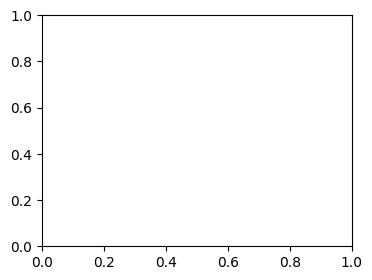

In [5]:


plot_heatmap(results_sgd, title='Runge function with SGD', heat_metric='MSE', filename=f'part_b-heatmap_50_100_{OPTIMIZER}', show_plot=SHOW_PLOT, save_image=SAVE_FIGURE)
"""
plot_heatmap(results_rmsprop, title='Runge function with RMSprop', heat_metric='MSE', filename=f'part_b-heatmap_50_100_{OPTIMIZER}', show_plot=SHOW_PLOT)
plot_heatmap(results_adam_no_penalty, title='Runge function with ADAM - no penalty', filename=f'part_b-heatmap_50_100_{OPTIMIZER}', show_plot=SHOW_PLOT)
plot_heatmap(results_adam_L1, title='Runge function with ADAM - L1', heat_metric='MSE', filename=f'part_b-heatmap_50_100_{OPTIMIZER}', show_plot=SHOW_PLOT)
plot_heatmap(results_adam_L2, title='Runge function with ADAM - L2', heat_metric='MSE', filename=f'part_b-heatmap_50_100_{OPTIMIZER}', show_plot=SHOW_PLOT)
"""


In [ ]:


# SGD
min_row = results_sgd.loc[results_sgd['MSE'].idxmin()]
predictions = min_row['Predictions'] # find predictions for lowest mse
plot_runges(x, y, x_test, predictions, title=f'Runge function - SGD', filename=f'part_b-runge_50_100_{OPTIMIZER}', show_plot=SHOW_PLOT, save_image=SAVE_FIGURE)

# RMSprop
min_row = results_rmsprop.loc[results_rmsprop['MSE'].idxmin()]
predictions = min_row['Predictions'] # find predictions for lowest mse
plot_runges(x, y, x_test, predictions, title=f'Runge function - RMSprop', filename=f'part_b-runge_50_100_{OPTIMIZER}', show_plot=SHOW_PLOT, save_image=SAVE_FIGURE)

# ADAM - no penalty
min_row = results_adam_no_penalty.loc[results_adam_no_penalty['MSE'].idxmin()]
predictions = min_row['Predictions'] # find predictions for lowest mse
plot_runges(x, y, x_test, predictions, title=f'Runge function - ADAM - no penalty', filename=f'part_b-runge_50_100_{OPTIMIZER}', show_plot=SHOW_PLOT, save_image=SAVE_FIGURE)

# ADAM - L1
min_row = results_adam_L1.loc[results_adam_L1['MSE'].idxmin()]
predictions = min_row['Predictions'] # find predictions for lowest mse
plot_runges(x, y, x_test, predictions, title=f'Runge function - ADAM - L1', filename=f'part_b-runge_50_100_{OPTIMIZER}', show_plot=SHOW_PLOT, save_image=SAVE_FIGURE)

# ADAM - L2
min_row = results_adam_L2.loc[results_adam_L2['MSE'].idxmin()]
predictions = min_row['Predictions'] # find predictions for lowest mse
plot_runges(x, y, x_test, predictions, title=f'Runge function - ADAM - L2', filename=f'part_b-runge_50_100_{OPTIMIZER}', show_plot=SHOW_PLOT, save_image=SAVE_FIGURE)

### Own implementation of FFNN

Hidden layers (50,)

In [ ]:
# Settings for own implementation

# Activation output always linear with regression
ACTIVATION_FUNCTION_OUTPUT = activation_functions.linear
ACTIVATION_FUNCTION_OUTPUT_DERIVATIVE = activation_functions.linear_derivative

# Hidden layers
ACTIVATION_FUNCTION = activation_functions.RELU
ACTIVATION_FUNCTION_DERIVATIVE = activation_functions.RELU_derivative
RUNGE_HIDDEN = (50,)

# Generate list of activation functions, and dimensions of layers
activations, activations_derivative, _dim = create_activations_layderdim(ACTIVATION_FUNCTION, ACTIVATION_FUNCTION_DERIVATIVE, ACTIVATION_FUNCTION_OUTPUT, ACTIVATION_FUNCTION_OUTPUT_DERIVATIVE, RUNGE_HIDDEN, y_train, x_train_scaled)

In [ ]:
# Hidden layers 50
print()
print(f'Dimensions of input, hidden, and output layer:\n{_dim}')
runge_NN = NN(dims = _dim, activation_funcs = activations, activation_ders = activations_derivative)

results_sgd_50 = neural_network_loop(runge_NN, ETA_VALUES, LAMBDA_VALUES, 'SGD', ITERATIONS, x_train_scaled, y_train, x_test, y_test, momentum_val=MOMENTUM, verbose=True)
results_rmsprop_50 = neural_network_loop(runge_NN, ETA_VALUES, LAMBDA_VALUES, 'RMSprop', ITERATIONS, x_train_scaled, y_train, x_test, y_test, momentum_val=MOMENTUM, verbose=True)
results_adam_no_penalty_50 = neural_network_loop(runge_NN, ETA_VALUES, LAMBDA_VALUES, 'ADAM', ITERATIONS, x_train_scaled, y_train, x_test, y_test, momentum_val=MOMENTUM, verbose=True)
results_adam_L1_50 = neural_network_loop(runge_NN, ETA_VALUES, LAMBDA_VALUES, 'ADAM_L1', ITERATIONS, x_train_scaled, y_train, x_test, y_test, momentum_val=MOMENTUM, verbose=True)
results_adam_L2_50 = neural_network_loop(runge_NN, ETA_VALUES, LAMBDA_VALUES, 'ADAM_L2', ITERATIONS, x_train_scaled, y_train, x_test, y_test, momentum_val=MOMENTUM, verbose=True)

In [ ]:


plot_heatmap(results_sgd_50 , title='Runge function with SGD', heat_metric='MSE', filename=f'part_b-heatmap_50_{OPTIMIZER}', show_plot=SHOW_PLOT, save_image=SAVE_FIGURE)
plot_heatmap(results_rmsprop_50 , title='Runge function with RMSprop', heat_metric='MSE', filename=f'part_b-heatmap_50_{OPTIMIZER}', show_plot=SHOW_PLOT, save_image=SAVE_FIGURE)
plot_heatmap(results_adam_no_penalty_50 , title='Runge function with ADAM - no penalty', heat_metric='MSE', filename=f'part_b-heatmap_50_{OPTIMIZER}', show_plot=SHOW_PLOT, save_image=SAVE_FIGURE)
plot_heatmap(results_adam_L1_50 , title='Runge function with ADAM - L1', heat_metric='MSE', filename=f'part_b-heatmap_50_{OPTIMIZER}', show_plot=SHOW_PLOT, save_image=SAVE_FIGURE)
plot_heatmap(results_adam_L2_50 , title='Runge function with ADAM - L2', heat_metric='MSE', filename=f'part_b-heatmap_50_{OPTIMIZER}', show_plot=SHOW_PLOT, save_image=SAVE_FIGURE)


In [ ]:


# SGD
min_row = results_sgd_50.loc[results_sgd_50['MSE'].idxmin()]
predictions = min_row['Predictions'] # find predictions for lowest mse
plot_runges(x, y, x_test, predictions, title=f'Runge function - SGD', filename=f'part_b-runge_50_{OPTIMIZER}', show_plot=SHOW_PLOT, save_image=SAVE_FIGURE)

# RMSprop
min_row = results_rmsprop_50.loc[results_rmsprop_50['MSE'].idxmin()]
predictions = min_row['Predictions'] # find predictions for lowest mse
plot_runges(x, y, x_test, predictions, title=f'Runge function - RMSprop', filename=f'part_b-runge_50_{OPTIMIZER}', show_plot=SHOW_PLOT, save_image=SAVE_FIGURE)

# ADAM - no penalty
min_row = results_adam_no_penalty_50.loc[results_adam_no_penalty_50['MSE'].idxmin()]
predictions = min_row['Predictions'] # find predictions for lowest mse
plot_runges(x, y, x_test, predictions, title=f'Runge function - ADAM - no penalty', filename=f'part_b-runge_50_{OPTIMIZER}', show_plot=SHOW_PLOT, save_image=SAVE_FIGURE)

# ADAM - L1
min_row = results_adam_L1_50.loc[results_adam_L1_50['MSE'].idxmin()]
predictions = min_row['Predictions'] # find predictions for lowest mse
plot_runges(x, y, x_test, predictions, title=f'Runge function - ADAM - L1', filename=f'part_b-runge_50_{OPTIMIZER}', show_plot=SHOW_PLOT, save_image=SAVE_FIGURE)

# ADAM - L2
min_row = results_adam_L2_50.loc[results_adam_L2_50['MSE'].idxmin()]
predictions = min_row['Predictions'] # find predictions for lowest mse
plot_runges(x, y, x_test, predictions, title=f'Runge function - ADAM - L2', filename=f'part_b-runge_50_{OPTIMIZER}', show_plot=SHOW_PLOT, save_image=SAVE_FIGURE)